In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import statsmodels.api as sm
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.cross_decomposition import PLSRegression
from xgboost import XGBRegressor
from xgboost import plot_importance


In [2]:
#Loading the data

df = pd.read_parquet('feature.parq')

In [3]:
#Renaming columns

df.columns = [df.columns[0]] + [f'f{i}' for i in range(1, len(df.columns))]
df.head()


,mid_prc,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f77,f78,f79,f80,f81,f82,f83,f84,f85,f86
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-04-16 00:00:05,1588.010010,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.000000,...,5.000000,5.000000,5.000000,5.0,5.000000,5.000000,5.000000,5.0,5.000000,5.0000
2025-04-16 00:00:06,1587.824951,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,0.601331,...,0.023879,-1.795081,5.000000,5.0,-0.614067,-5.000000,5.000000,5.0,-0.774996,-5.0000
2025-04-16 00:00:07,1587.824951,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,0.322740,...,0.766593,5.000000,5.000000,5.0,0.142544,3.931395,5.000000,5.0,-0.024244,-3.6261
2025-04-16 00:00:08,1587.305054,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,-5.000000,...,-5.000000,-5.000000,-4.450434,-5.0,-5.000000,-5.000000,-4.419014,-5.0,-5.000000,-5.0000
2025-04-16 00:00:09,1587.285034,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,-5.0,-5.000000,...,-5.000000,-5.000000,-4.941638,-5.0,-5.000000,-5.000000,-4.966719,-5.0,-5.000000,-5.0000


In [4]:
#Verifying missing data on how dates aren't there

print(df.index.min())
print(df.index.max())
d = df.index.to_series().diff()
print(d.max())
print(d.min())
print(len(d[d== pd.Timedelta(seconds=2)]))
print(print((d[d== pd.Timedelta(seconds=3)])))


2025-04-16 00:00:05
2025-04-22 23:59:59
0 days 00:00:03
0 days 00:00:01
413
timestamp
2025-04-17 00:00:05   0 days 00:00:03
2025-04-22 00:00:04   0 days 00:00:03
Name: timestamp, dtype: timedelta64[ns]
None


**Out of 650k records, only 413 seconds of data is missing and thereby, isn't necessary enough to fill them**

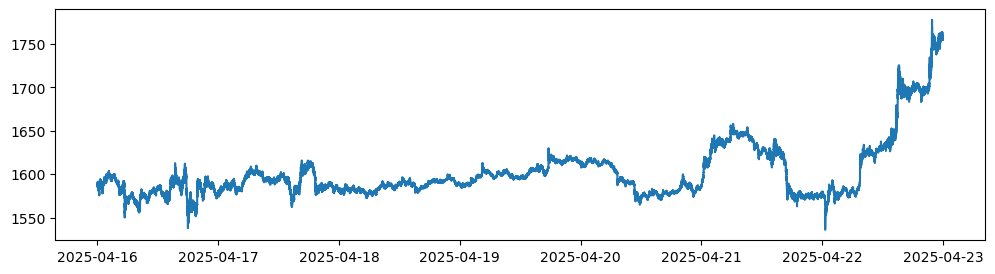

In [5]:
plt.figure(figsize=(12,3))
plt.plot(df['mid_prc'])
plt.show()

**Steady price for the first almost 6 days with super high volatility on Day 7 from opening**

In [6]:
#Creating shifted returns for predictive power generation

df['returns'] = np.log(df['mid_prc'] / df['mid_prc'].shift(1)) * 100
df[f'returns_shift_1'] = df['returns'].shift(-1)


In [7]:
#Train-test splitting of data

X = df.values
y = df['returns_shift_1'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=False)

In [ ]:
#Creating a new dataframe after splitting data - new_df is just the train dataset in df format

new_df = pd.DataFrame(X_train)
new_df['returns_shift_1'] = y_train
new_df.columns.values[0] = 'mid_prc'
new_df

,mid_prc,1,2,3,4,5,6,7,8,9,...,78,79,80,81,82,83,84,85,86,returns_shift_1
0,1588.010010,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,-0.011653
1,1587.824951,-5.000000,-5.000000,-5.000000,-5.000000,-5.000000,-5.000000,-5.000000,-5.000000,0.601331,...,-1.795081,5.000000,5.000000,-0.614067,-5.000000,5.000000,5.000000,-0.774996,-5.000000,0.000000
2,1587.824951,-5.000000,-5.000000,-5.000000,-5.000000,-5.000000,-5.000000,-5.000000,-5.000000,0.322740,...,5.000000,5.000000,5.000000,0.142544,3.931395,5.000000,5.000000,-0.024244,-3.626100,-0.032746
3,1587.305054,-5.000000,-5.000000,-5.000000,-5.000000,-5.000000,-5.000000,-5.000000,-5.000000,-5.000000,...,-5.000000,-4.450434,-5.000000,-5.000000,-5.000000,-4.419014,-5.000000,-5.000000,-5.000000,-0.001264
4,1587.285034,-5.000000,-5.000000,-5.000000,-5.000000,-5.000000,-5.000000,-5.000000,-5.000000,-5.000000,...,-5.000000,-4.941638,-5.000000,-5.000000,-5.000000,-4.966719,-5.000000,-5.000000,-5.000000,0.006926
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
423059,1590.234985,0.187653,-0.205063,-0.294818,-0.294818,0.384975,0.324708,0.127975,0.127975,0.125362,...,0.895781,0.858569,0.885159,1.763876,0.932048,0.800373,0.885315,1.846933,0.966327,0.000000
423060,1590.234985,0.442364,-0.072251,-0.209293,-0.209293,0.571029,0.523087,0.295832,0.295832,0.059566,...,0.895508,0.871177,0.884893,1.735646,0.931755,0.819962,0.885049,1.834066,0.966011,0.010061
423061,1590.395020,-0.004306,-0.587807,-0.614311,-0.614311,-0.410322,0.245579,0.902693,0.902693,1.487970,...,0.895115,1.767036,0.884508,2.220679,0.931331,1.598763,0.884664,2.198334,0.965557,-0.003779
423062,1590.334961,-0.657712,-0.644728,-0.654655,-0.654655,-0.324804,-0.542008,1.152387,1.152387,0.326737,...,0.894921,1.181005,0.884318,2.004448,0.931121,1.089195,0.884475,2.036417,0.965332,-0.010372


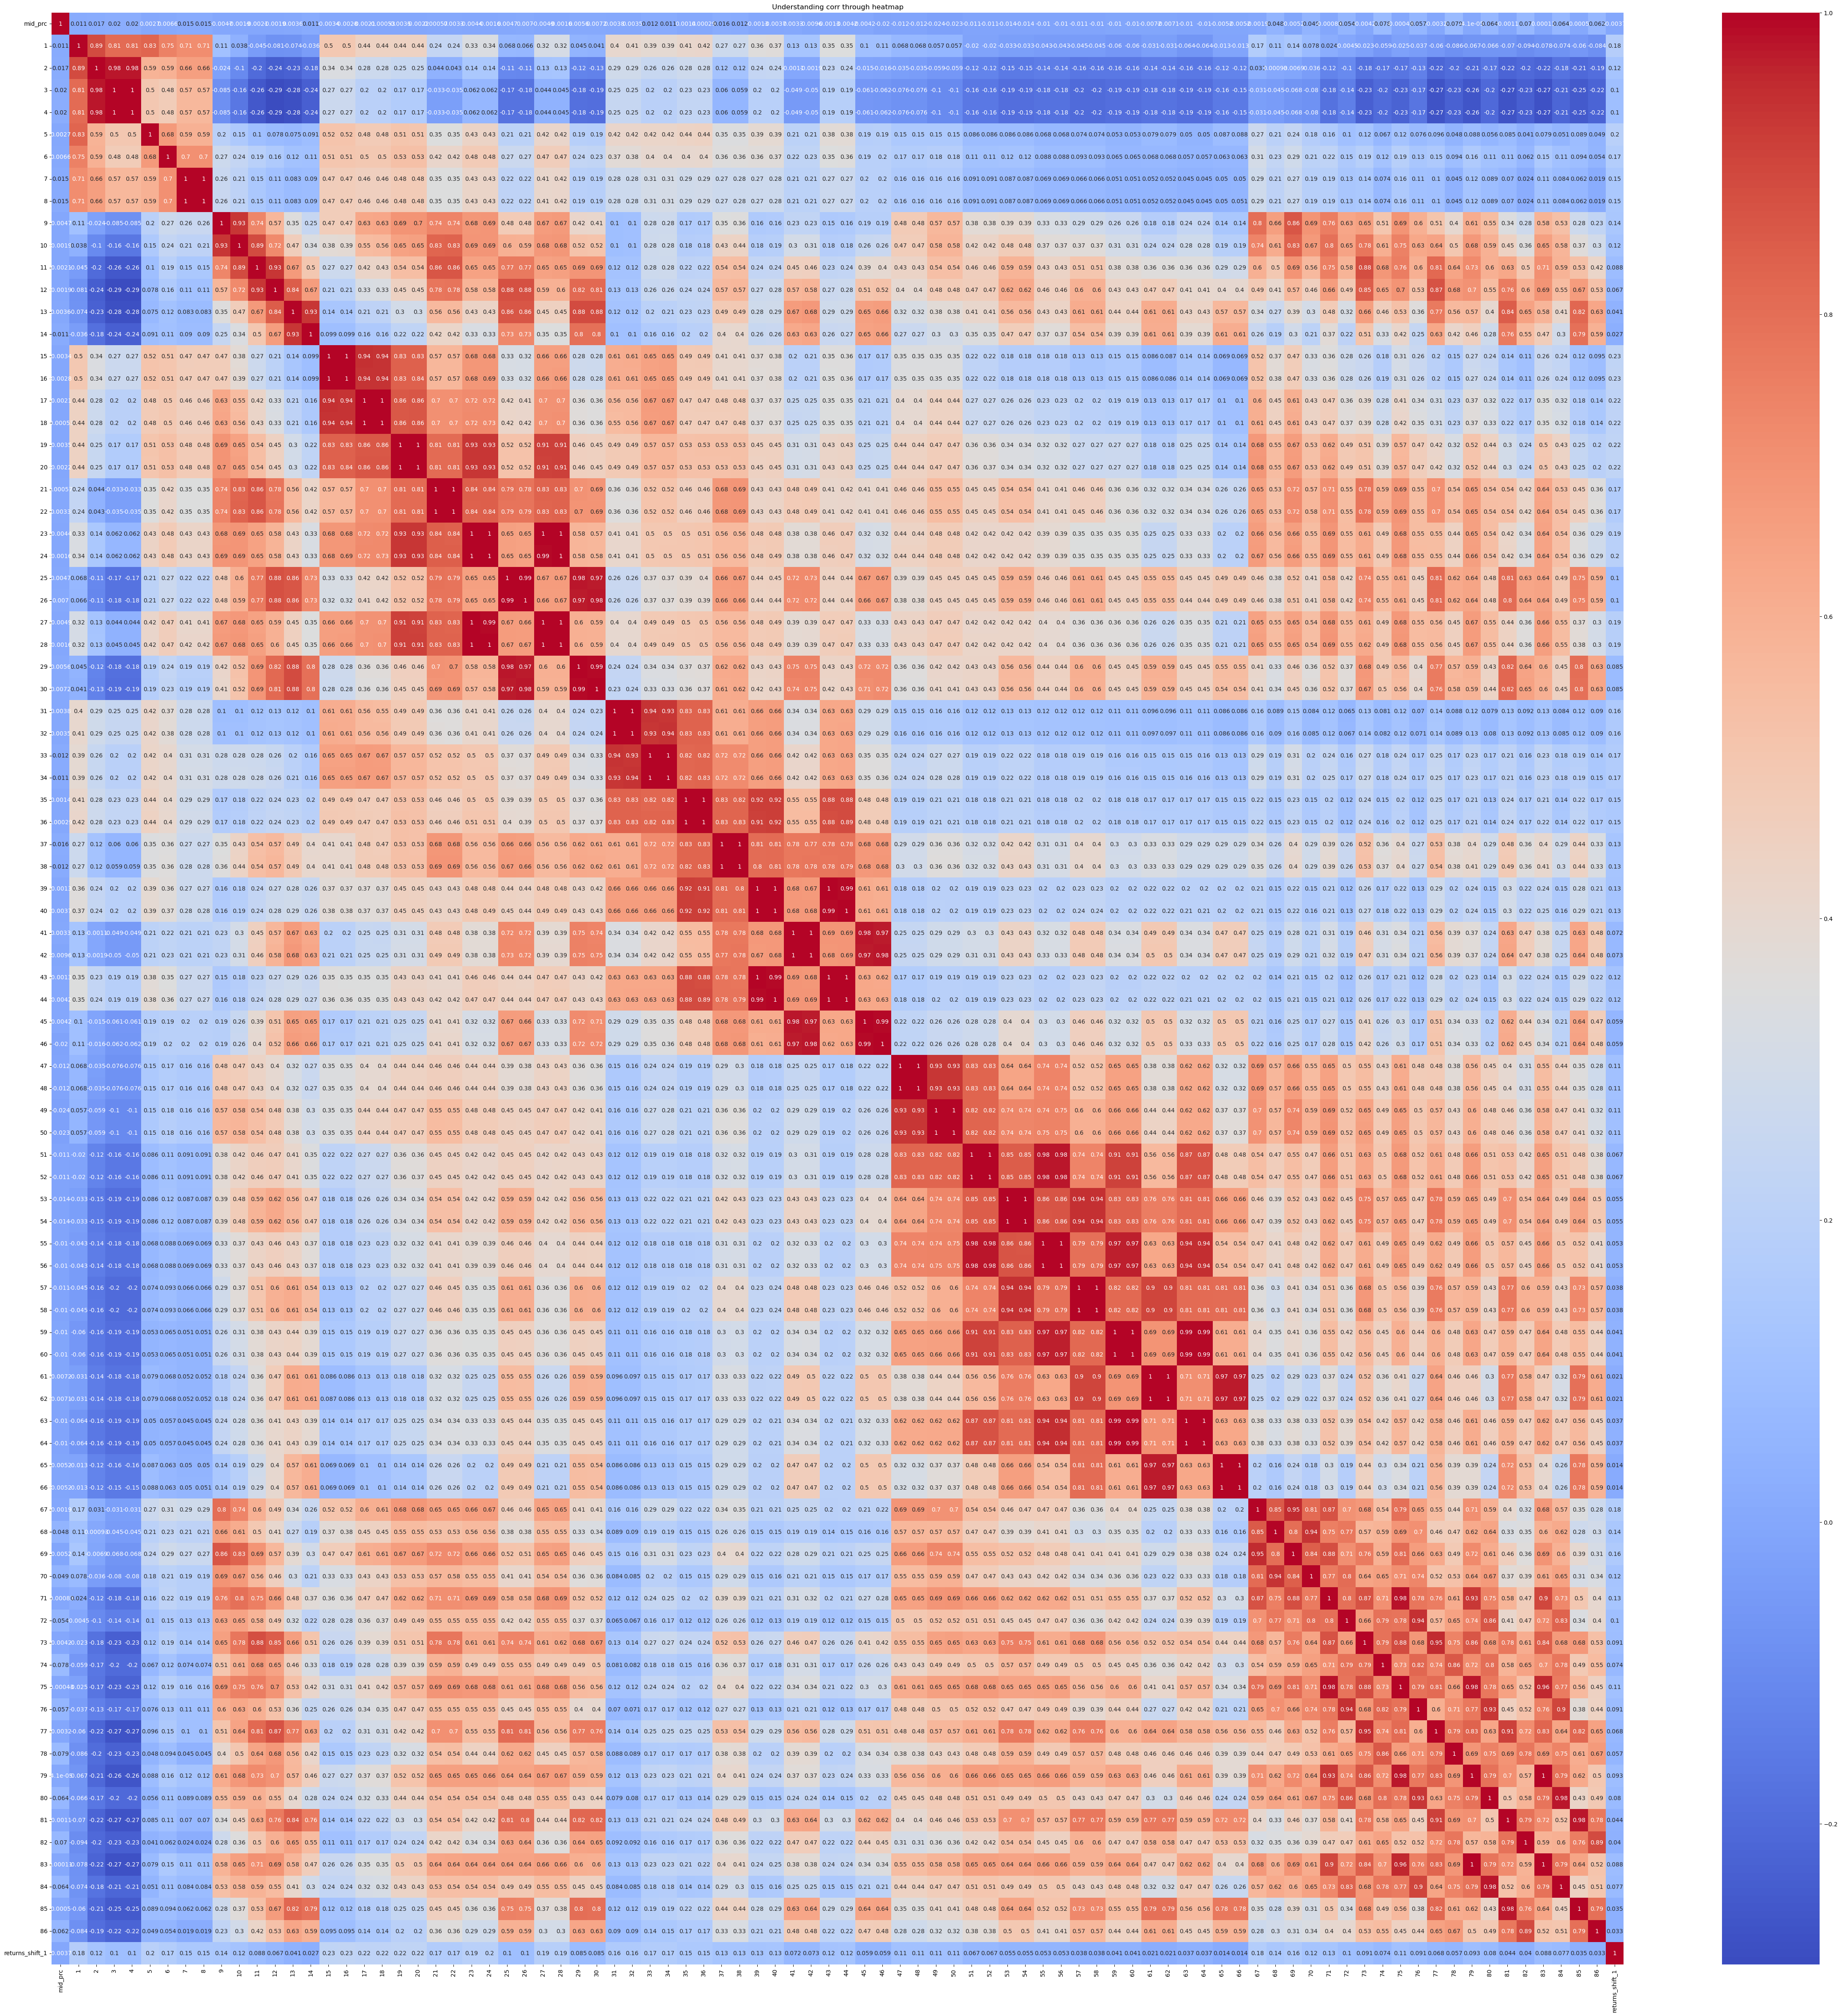

In [9]:
#Generating a feature correlation heatmap

correlation  = new_df.corr(method='spearman')
plt.figure(figsize=(60,60))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Understanding corr through heatmap')
plt.show()

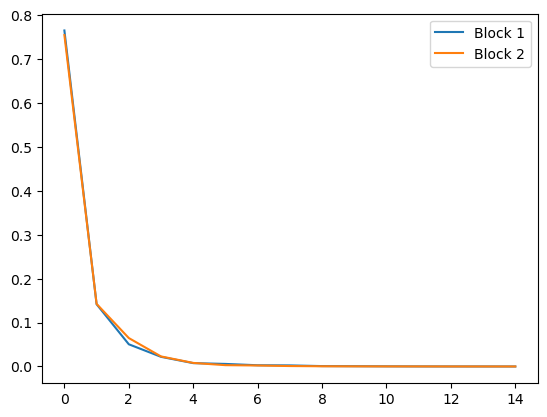

In [11]:
from sklearn.decomposition import PCA

pca1 = PCA().fit(new_df.iloc[:, 15:30])
pca2 = PCA().fit(new_df.iloc[:,  31:46])

plt.plot(pca1.explained_variance_ratio_, label="Block 1")
plt.plot(pca2.explained_variance_ratio_, label="Block 2")
plt.legend()

In [16]:
#Making each block only 2 features each

pca1 = PCA(n_components=2).fit_transform(new_df.iloc[:, 15:30])
pca2 = PCA(n_components=2).fit_transform(new_df.iloc[:, 31:46])

new_df["block1_PC1"] = pca1[:, 0]
new_df["block2_PC1"] = pca2[:, 0]

corr_pca = new_df[["block1_PC1", "block2_PC1", "returns_shift_1"]].corr(method="spearman")
print(corr_pca)

                 block1_PC1  block2_PC1  returns_shift_1
block1_PC1         1.000000    0.589637         0.209365
block2_PC1         0.589637    1.000000         0.144840
returns_shift_1    0.209365    0.144840         1.000000


In [17]:
X_block1 = new_df.iloc[:, 15:30].values
X_block2 = new_df.iloc[:, 31:46].values
y = new_df["returns_shift_1"].values.reshape(-1,1)

# Fit PLS separately
pls1 = PLSRegression(n_components=1)
pls1.fit(X_block1, y)
new_df["PLS_block1"] = pls1.transform(X_block1)[:,0]

pls2 = PLSRegression(n_components=1)
pls2.fit(X_block2, y)
new_df["PLS_block2"] = pls2.transform(X_block2)[:,0]

# Fit PLS on combined
import numpy as np
X_all = np.hstack([X_block1, X_block2])
pls_comb = PLSRegression(n_components=1)
pls_comb.fit(X_all, y)
new_df["PLS_combined"] = pls_comb.transform(X_all)[:,0]

In [21]:
from scipy.stats import spearmanr

corr_block1 = spearmanr(new_df["PLS_block1"], new_df["returns_shift_1"])
corr_block2 = spearmanr(new_df["PLS_block2"], new_df["returns_shift_1"])
corr_comb = spearmanr(new_df["PLS_combined"], new_df["returns_shift_1"])

print("Spearman ICs (train data):")
print("Block 1:", corr_block1.correlation)
print("Block 2:", corr_block2.correlation)
print("Combined:", corr_comb.correlation)

Spearman ICs (train data):
Block 1: 0.21500838271002704
Block 2: 0.1532117275634913
Combined: 0.20904495855273858


In [ ]:
from scipy.stats import rankdata, spearmanr

window_size = 300  # seconds
step = 5          # compute every 5 seconds
block1_features = new_df.iloc[:, 15:30].values  # numpy for speed
block2_features = new_df.iloc[:, 31:46].values
timestamps = new_df.index.values
n_features = block1_features.shape[1]

def mean_spearman_vector(window_data):
    # window_data: W x n_features
    ranks = np.apply_along_axis(rankdata, 0, window_data)  # rank each column
    ranks = ranks - ranks.mean(axis=0)  # center
    cov = ranks.T @ ranks / (ranks.shape[0] - 1)  # covariance of ranks
    std = np.sqrt(np.diag(cov))
    corr_matrix = cov / (std[:,None] * std[None,:])  # Spearman corr matrix
    mean_corr_per_feature = corr_matrix.mean(axis=1)
    return mean_corr_per_feature

pattern_vectors_block1 = []
pattern_vectors_block2 = []
pattern_times = []

for start in range(0, len(new_df) - window_size + 1, step):
    end = start + window_size
    window_block1 = block1_features[start:end, :]
    window_block2 = block2_features[start:end, :]

    vec1 = mean_spearman_vector(window_block1)
    vec2 = mean_spearman_vector(window_block2)

    pattern_vectors_block1.append(vec1)
    pattern_vectors_block2.append(vec2)
    pattern_times.append(timestamps[end-1])

pattern_vectors_block1 = pd.DataFrame(pattern_vectors_block1, index=pattern_times)
pattern_vectors_block2 = pd.DataFrame(pattern_vectors_block2, index=pattern_times)

pattern_agreement = [
    spearmanr(pattern_vectors_block1.iloc[i], pattern_vectors_block2.iloc[i]).correlation
    for i in range(len(pattern_vectors_block1))
]
pattern_agreement_series = pd.Series(pattern_agreement, index=pattern_times)

block1_score_aligned = new_df["PLS_block1"].reindex(pattern_times)
final_signal = block1_score_aligned * (1 + pattern_agreement_series)

In [ ]:
returns_aligned = new_df["returns_shift_1"].reindex(pattern_agreement_series.index)
ic_overall = spearmanr(final_signal, returns_aligned).correlation
print("Overall IC:", ic_overall)

# Conditional IC by agreement quantile
quantiles = pd.qcut(pattern_agreement_series, 5, labels=False)
for q in range(5):
    mask = quantiles == q
    ic_q, _ = spearmanr(final_signal[mask], returns_aligned[mask])
    print(f"IC in pattern agreement quantile {q}: {ic_q:.4f}")

Overall IC: 0.21669408870165466
IC in pattern agreement quantile 0: 0.2470
IC in pattern agreement quantile 1: 0.2072
IC in pattern agreement quantile 2: 0.2205
IC in pattern agreement quantile 3: 0.2163
IC in pattern agreement quantile 4: 0.2003


**The repeating pattern while relevant because of high correlation to the target variable, might just be an outcome of data synthetization**

***Attempting XG Boost***

In [32]:
# Creating a correlation-shifted
correlation_with_shift = correlation['returns_shift_1'].sort_values(ascending=False)
correlation_with_shift = correlation_with_shift.to_frame().rename(columns={'returns_shift_1': 'corr'})
features = correlation_with_shift.index  # feature names

# Compute lag-1 autocorrelation for each feature
correlation_with_shift['auto_corr'] = [new_df[f].autocorr(lag=1) for f in features]

# Compute product of correlation and autocorrelation
correlation_with_shift['corr_prod'] = correlation_with_shift['corr'] * correlation_with_shift['auto_corr']


In [33]:
#Inspect top correlated features
top_corr_features = correlation_with_shift.sort_values(by='corr', ascending=False).head(20)
print("Top 20 features by correlation with target:")
print(top_corr_features)

#Filter features by thresholds
filtered_features = correlation_with_shift[
    (correlation_with_shift['corr'] > 0.15) &
    (correlation_with_shift['auto_corr'] > 0.6)
]
print("Features with corr>0.15 and lag-1 autocorr>0.6:")
print(filtered_features)

# 6Autocorrelation for all features
all_autocorr = pd.DataFrame({
    'auto_corr': [new_df[f].autocorr(lag=1) for f in new_df.columns]
}, index=new_df.columns)

top_autocorr = all_autocorr.sort_values(by='auto_corr', ascending=False).head(20)
print("Top 20 features by lag-1 autocorrelation:")
print(top_autocorr)

Top 20 features by correlation with target:
                     corr  auto_corr  corr_prod
returns_shift_1  1.000000   0.070419   0.070419
16               0.227475   0.219551   0.049942
15               0.227096   0.210189   0.047733
20               0.223605   0.550360   0.123063
19               0.222950   0.535405   0.119369
18               0.220337   0.377805   0.083245
17               0.219800   0.370253   0.081382
24               0.195595   0.685498   0.134080
5                0.195318   0.600899   0.117366
23               0.194521   0.676037   0.131503
28               0.189719   0.704373   0.133633
27               0.188539   0.696752   0.131365
1                0.178625   0.633672   0.113190
67               0.176575   0.521066   0.092007
6                0.172617   0.690806   0.119245
34               0.170965   0.413702   0.070729
33               0.170081   0.408819   0.069532
22               0.166979   0.791705   0.132198
21               0.166622   0.782976   0.130

***Based on what we saw earlier, and the information generated here, it looks like there's somethign we can derive from features 15-20***

In [68]:
##Resetting new_df
new_df = pd.DataFrame(X_train)
new_df['returns_shift_1'] = y_train
new_df.columns.values[0] = 'mid_prc'
new_df = new_df.drop(columns=[87,88])

In [69]:
#PLS for the features with high both

pls_features = [15, 16, 17, 18, 19, 20]  # columns to summarize

pls = PLSRegression(n_components=1)
X_pls_input = new_df[pls_features]
y_target = new_df['returns_shift_1']

pls_component = pls.fit_transform(X_pls_input, y_target)[0]

new_df_pls = new_df.drop(columns=pls_features).copy()
new_df_pls['pls_15_20'] = pls_component  # add as new column

In [72]:
#Clean dataset for modeling

df_clean = new_df_pls.drop(columns=['mid_prc']).dropna()

# Prepare feature matrix and target as DataFrames/Series
X_xgb_df = df_clean.drop(columns=['returns_shift_1'])  # keep column names
y_xgb = df_clean['returns_shift_1']


X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_xgb_df, y_xgb, test_size=0.2, shuffle=False
)

print("Columns in training set:", X_train_xgb.columns)


Columns in training set: Index([          1,           2,           3,           4,           5,
                 6,           7,           8,           9,          10,
                11,          12,          13,          14,          21,
                22,          23,          24,          25,          26,
                27,          28,          29,          30,          31,
                32,          33,          34,          35,          36,
                37,          38,          39,          40,          41,
                42,          43,          44,          45,          46,
                47,          48,          49,          50,          51,
                52,          53,          54,          55,          56,
                57,          58,          59,          60,          61,
                62,          63,          64,          65,          66,
                67,          68,          69,          70,          71,
                72,          73,       

In [ ]:
# Non-zero returns get higher weight
weight_factor = 5.0  
sample_weight = np.where(y_train_xgb.values != 0, weight_factor, 1.0)

In [ ]:
#Training XGBoost

xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(
    X_train_xgb.values,
    y_train_xgb.values,
    sample_weight=sample_weight
)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
y_model_prediction_xgb = xgb_model.predict(X_test_xgb.values)


# RMSE
rmse = np.sqrt(mean_squared_error(y_test_xgb.values, y_model_prediction_xgb))
print("Test RMSE:", rmse)

# R^2
r2 = r2_score(y_test_xgb.values, y_model_prediction_xgb)
print("Test R^2:", r2)

# Spearman IC
spearman_ic, _ = spearmanr(y_test_xgb.values, y_model_prediction_xgb)
print("Test Spearman IC:", spearman_ic)

Test RMSE: 0.006702729762556945
Test R^2: -0.07232964038848877
Test Spearman IC: 0.27653755449367773


In [ ]:
#Calculating sharpe ratio

strategy_returns = np.sign(y_model_prediction_xgb) * y_test_xgb.values
sharpe_ratio = strategy_returns.mean() / strategy_returns.std()
print(f"Sharpe ratio: {sharpe_ratio:.4f}")
annual_factor = np.sqrt(365 * 34 * 3600)
sharpe_annual = sharpe_ratio * annual_factor
print(f"Annualized Sharpe ratio: {sharpe_annual:.2f}")

Sharpe ratio: 0.1409
Annualized Sharpe ratio: 942.08


In [ ]:

#  Filter for non-zero actual returns and find values in test of old train (validation set almost)
nonzero_mask = y_test_xgb.values != 0
y_actual_nonzero = y_test_xgb.values[nonzero_mask]
y_pred_nonzero = y_model_prediction_xgb[nonzero_mask]

pred_sign = np.sign(y_pred_nonzero)

strategy_returns_nonzero = pred_sign * y_actual_nonzero

sharpe_ratio = strategy_returns_nonzero.mean() / strategy_returns_nonzero.std()
print(f"Sharpe ratio (non-zero returns only): {sharpe_ratio:.4f}")

hit_rate = (pred_sign == np.sign(y_actual_nonzero)).mean()
print(f"Hit rate (non-zero returns): {hit_rate:.4f}")

Sharpe ratio (non-zero returns only): 0.2859
Hit rate (non-zero returns): 0.7267


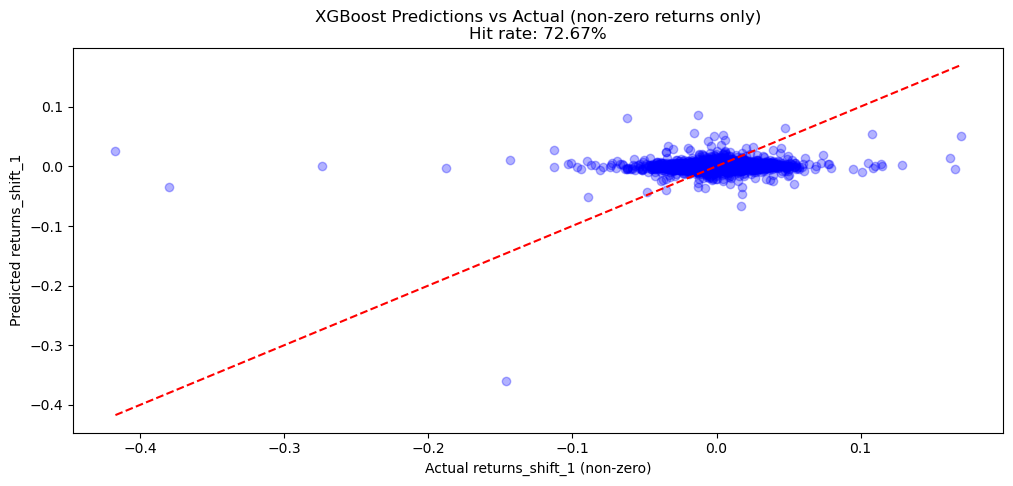

In [100]:
# 3️⃣ Scatter plot of predicted vs actual returns
plt.figure(figsize=(12,5))
plt.scatter(y_actual_nonzero, y_pred_nonzero, alpha=0.3, color='blue')
plt.xlabel("Actual returns_shift_1 (non-zero)")
plt.ylabel("Predicted returns_shift_1")
plt.title(f"XGBoost Predictions vs Actual (non-zero returns only)\nHit rate: {hit_rate:.2%}")
plt.plot([y_actual_nonzero.min(), y_actual_nonzero.max()],
         [y_actual_nonzero.min(), y_actual_nonzero.max()],
         color='red', linestyle='--')  # y=x reference line
plt.show()

**Trying out-of-sample model prediction**

In [107]:
# Assume pls_component was fitted on training features X_pls_input_train
# Extract same columns from X_test
X_test_df = pd.DataFrame(X_test, columns=df.columns) 
pls_features_for_df = [f'f{i}' for i in range(15, 21)]  # f15 to f20 # optional, for convenience
X_pls_input_test = X_test_df[pls_features_for_df]  # features 15-20 in test set

# # Transform test features using trained PLS
pls_component_test = pls.transform(X_pls_input_test)[:,0]

# # Drop original PLS features and add the component
X_test_df_pls = X_test_df.drop(columns=pls_features_for_df).copy()
X_test_df_pls['pls_15_20'] = pls_component_test



/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but PLSRegression was fitted without feature names
  warnings.warn(


In [111]:
X_test_xgb_oos = X_test_df_pls.drop(columns=['mid_prc', 'returns', 'returns_shift_1'])  # drop columns not in model
y_test_xgb_oos = y_test  # original shifted returns from initial split

In [112]:
y_pred_xgb_oos = xgb_model.predict(X_test_xgb_oos.values)

In [117]:
valid_mask = ~np.isnan(y_test_xgb_oos) & ~np.isnan(y_pred_xgb_oos)
y_test_xgb_oos = y_test_xgb_oos[valid_mask]
y_pred_xgb_oos = y_pred_xgb_oos[valid_mask]

strategy_all = np.sign(y_pred_xgb_oos) * y_test_xgb_oos
hit_all = (np.sign(y_pred_xgb_oos) == np.sign(y_test_xgb_oos)).mean()
sharpe_all = strategy_all.mean() / strategy_all.std()

print(f"OOS Hit rate (all returns): {hit_all:.4f}")
print(f"OOS Sharpe ratio (all returns): {sharpe_all:.4f}")

OOS Hit rate (all returns): 0.3171
OOS Sharpe ratio (all returns): 0.0979


In [118]:
nonzero_mask = y_test_xgb_oos != 0
strategy_nonzero = np.sign(y_pred_xgb_oos[nonzero_mask]) * y_test_xgb_oos[nonzero_mask]
hit_nonzero = (np.sign(y_pred_xgb_oos[nonzero_mask]) == np.sign(y_test_xgb_oos[nonzero_mask])).mean()
sharpe_nonzero = strategy_nonzero.mean() / strategy_nonzero.std()

print(f"OOS Hit rate (non-zero returns): {hit_nonzero:.4f}")
print(f"OOS Sharpe ratio (non-zero returns): {sharpe_nonzero:.4f}")


OOS Hit rate (non-zero returns): 0.6173
OOS Sharpe ratio (non-zero returns): 0.1372


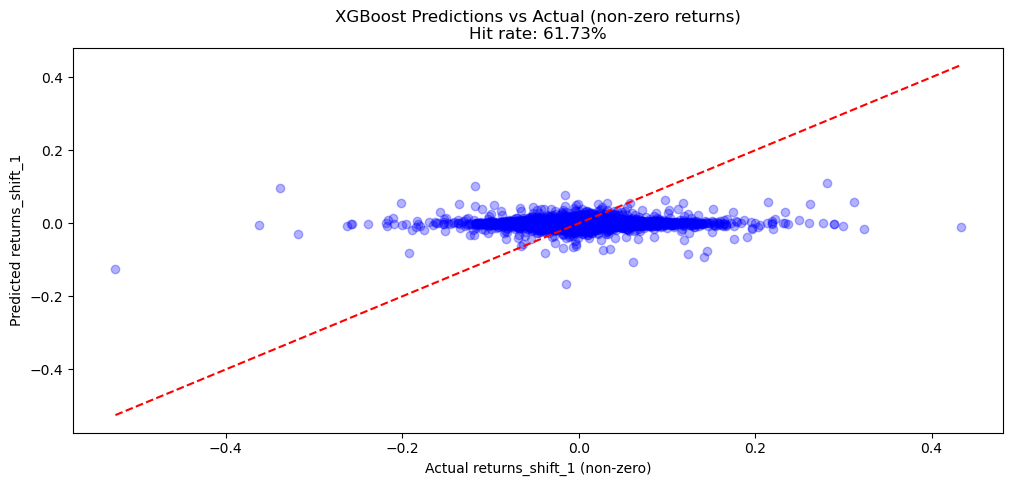

In [119]:
plt.figure(figsize=(12,5))
plt.scatter(
    y_test_xgb_oos[nonzero_mask],
    y_pred_xgb_oos[nonzero_mask],
    alpha=0.3,
    color='blue'
)
plt.xlabel("Actual returns_shift_1 (non-zero)")
plt.ylabel("Predicted returns_shift_1")
plt.title(f"XGBoost Predictions vs Actual (non-zero returns)\nHit rate: {hit_nonzero:.2%}")
plt.plot(
    [y_test_xgb_oos[nonzero_mask].min(), y_test_xgb_oos[nonzero_mask].max()],
    [y_test_xgb_oos[nonzero_mask].min(), y_test_xgb_oos[nonzero_mask].max()],
    color='red', linestyle='--'
)
plt.show()